In [3]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import math
import statistics
import warnings
warnings.filterwarnings(action='ignore')
pd.options.display.float_format = '{:.5f}'.format
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

temp_data=pd.read_csv("/Users/kbh/Downloads/lending_club_2020_train.csv",low_memory=False)
temp_data2=pd.read_csv("Downloads/LCDataDictionary.xlsx - LoanStats.csv")



FileNotFoundError: [Errno 2] No such file or directory: 'Downloads/LCDataDictionary.xlsx - LoanStats.csv'

In [5]:
temp_data.loc[temp_data['mort_acc']>=20,['mort_acc','loan_status','funded_amnt','term','sub_grade','grade','purpose','annual_inc']]

,mort_acc,loan_status,funded_amnt,term,sub_grade,grade,purpose,annual_inc
9671,21.00000,Current,15950.00000,36 months,B4,B,home_improvement,65000.00000
16715,21.00000,Current,40000.00000,36 months,A1,A,debt_consolidation,420000.00000
22982,27.00000,Fully Paid,6200.00000,60 months,G1,G,debt_consolidation,185000.00000
35417,21.00000,Charged Off,35000.00000,60 months,C2,C,debt_consolidation,400000.00000
37163,20.00000,Current,31850.00000,60 months,B3,B,debt_consolidation,210000.00000
38524,22.00000,Current,20000.00000,60 months,C1,C,credit_card,195000.00000
47722,21.00000,Fully Paid,40000.00000,60 months,C4,C,debt_consolidation,225000.00000
50182,28.00000,Current,40000.00000,60 months,B3,B,home_improvement,85000.00000
68492,21.00000,Current,10000.00000,36 months,A3,A,home_improvement,193650.00000
80631,20.00000,Current,19125.00000,60 months,A4,A,other,150000.00000


In [15]:
a=temp_data.loc[(temp_data['mort_acc']>=10) & (temp_data['mort_acc']<=30),['annual_inc','issue_d','mort_acc','funded_amnt','emp_title','dti','loan_status']]
a

,annual_inc,issue_d,mort_acc,funded_amnt,emp_title,dti,loan_status
250,102000.00000,Feb-2014,10.00000,35000.00000,manager,17.45000,Fully Paid
622,85000.00000,Oct-2012,12.00000,16000.00000,"Amgen, Inc",9.56000,Fully Paid
988,100000.00000,Apr-2016,10.00000,8000.00000,limo driver,7.31000,Fully Paid
1266,230000.00000,Mar-2014,16.00000,21000.00000,Sales,4.52000,Fully Paid
1621,150000.00000,Feb-2015,12.00000,10000.00000,Physician Associate,12.95000,Fully Paid
1676,220000.00000,Mar-2016,10.00000,15000.00000,physician,8.25000,Fully Paid
1975,178000.00000,Jul-2016,17.00000,16000.00000,Director of Operations,14.23000,Fully Paid
2045,350000.00000,Jan-2019,11.00000,35000.00000,EVP/ partner,10.92000,Current
2663,104000.00000,Jun-2013,11.00000,20000.00000,Pearson Education,21.57000,Fully Paid
2739,285000.00000,Feb-2016,12.00000,35000.00000,Sales Channel engineer,10.73000,Fully Paid


In [13]:
sum(a['loan_status']=='Fully Paid')

3252

In [97]:
temp_data['int_rate'] = temp_data['int_rate'].str.replace('%', '').astype(float)

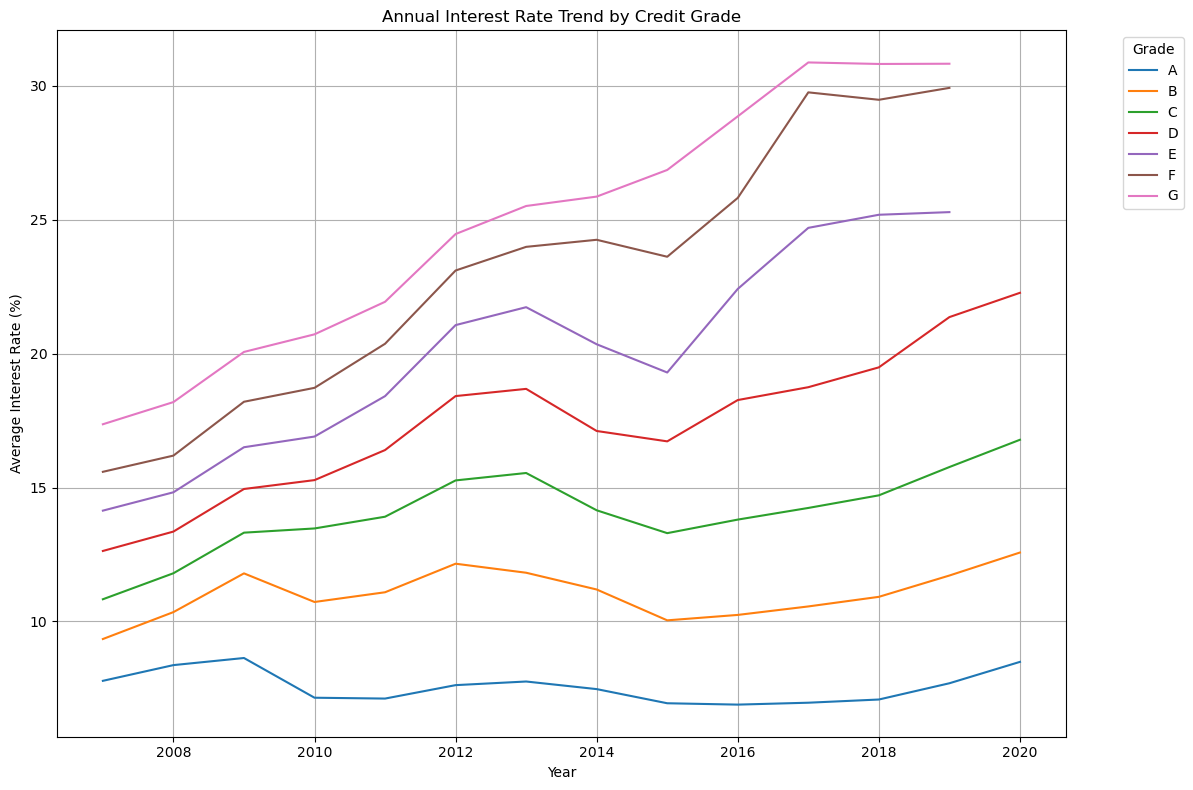

In [117]:
temp_data['year'] = pd.to_datetime(temp_data['issue_d']).dt.year
grouped_data=temp_data.groupby(['year', 'grade'])['int_rate'].mean().unstack()
plt.figure(figsize=(12, 8))
for sub_grade in grouped_data.columns:
    plt.plot(grouped_data.index, grouped_data[sub_grade], label=sub_grade)

plt.title('Annual Interest Rate Trend by Credit Grade')
plt.xlabel('Year')
plt.ylabel('Average Interest Rate (%)')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig('/Users/kbh/Downloads/lending club/grade_int_rage.png')
plt.show()


In [36]:
temp_data2=pd.read_csv("/Users/kbh/Downloads/LCDataDictionary.xlsx - LoanStats.csv",low_memory=False)

In [38]:
temp_data2.head()

,LoanStatNew,Description
0,acc_now_delinq,The number of accounts on which the borrower i...
1,acc_open_past_24mths,Number of trades opened in past 24 months.
2,addr_state,The state provided by the borrower in the loan...
3,all_util,Balance to credit limit on all trades
4,annual_inc,The self-reported annual income provided by th...


In [40]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None) 

In [42]:
for i in range(0,len(temp_data.columns)):
    temp_data.iloc[:,i].info()
    sumna=temp_data.iloc[:,i].isnull().sum()
    print(str(i+1) + "'s NaN : " + str(sumna) )

<class 'pandas.core.series.Series'>
RangeIndex: 1755295 entries, 0 to 1755294
Series name: id
Non-Null Count    Dtype 
--------------    ----- 
1755295 non-null  object
dtypes: object(1)
memory usage: 13.4+ MB
1's NaN : 0
<class 'pandas.core.series.Series'>
RangeIndex: 1755295 entries, 0 to 1755294
Series name: loan_amnt
Non-Null Count    Dtype 
--------------    ----- 
1755295 non-null  object
dtypes: object(1)
memory usage: 13.4+ MB
2's NaN : 0
<class 'pandas.core.series.Series'>
RangeIndex: 1755295 entries, 0 to 1755294
Series name: funded_amnt
Non-Null Count    Dtype 
--------------    ----- 
1755295 non-null  object
dtypes: object(1)
memory usage: 13.4+ MB
3's NaN : 0
<class 'pandas.core.series.Series'>
RangeIndex: 1755295 entries, 0 to 1755294
Series name: funded_amnt_inv
Non-Null Count    Dtype 
--------------    ----- 
1755295 non-null  object
dtypes: object(1)
memory usage: 13.4+ MB
4's NaN : 0
<class 'pandas.core.series.Series'>
RangeIndex: 1755295 entries, 0 to 1755294
Serie

In [7]:
len(temp_data.columns)

141

In [43]:
temp_data.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title',
       ...
       'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
       'hardship_length', 'hardship_dpd', 'hardship_loan_status',
       'orig_projected_additional_accrued_interest',
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'debt_settlement_flag'],
      dtype='object', length=141)

In [46]:
list1=list(temp_data2['LoanStatNew'].iloc[0:151])

In [48]:
list1

['acc_now_delinq',
 'acc_open_past_24mths',
 'addr_state',
 'all_util',
 'annual_inc',
 'annual_inc_joint',
 'application_type',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'collection_recovery_fee',
 'collections_12_mths_ex_med',
 'delinq_2yrs',
 'delinq_amnt',
 'desc',
 'dti',
 'dti_joint',
 'earliest_cr_line',
 'emp_length',
 'emp_title',
 'fico_range_high',
 'fico_range_low',
 'funded_amnt',
 'funded_amnt_inv',
 'grade',
 'home_ownership',
 'id',
 'il_util',
 'initial_list_status',
 'inq_fi',
 'inq_last_12m',
 'inq_last_6mths',
 'installment',
 'int_rate',
 'issue_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'last_pymnt_amnt',
 'last_pymnt_d',
 'loan_amnt',
 'loan_status',
 'max_bal_bc',
 'member_id',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_last_delinq',
 'mths_since_last_major_derog',
 'mths_since_last_record',
 'mths_since_rcnt_il',
 'mth

In [50]:
columns_in_list1 = [col for col in temp_data.columns if col in list1]

In [52]:
columns_in_list1

['id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'acc_now_d

In [54]:
columns_not_in_list1 = [col for col in temp_data.columns if col not in list1]
columns_not_in_list1

['verification_status_joint',
 'total_rev_hi_lim',
 'revol_bal_joint',
 'sec_app_fico_range_low',
 'sec_app_fico_range_high',
 'sec_app_earliest_cr_line',
 'sec_app_inq_last_6mths',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_revol_util',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med']

In [39]:
temp_data['verification_status_joint'] # same as verified_status_joint

0          Verified
1               NaN
2               NaN
3               NaN
4          Verified
             ...   
1755290         NaN
1755291         NaN
1755292         NaN
1755293         NaN
1755294         NaN
Name: verification_status_joint, Length: 1755295, dtype: object

In [23]:
temp_data['verification_status']

0                 Verified
1          Source Verified
2                 Verified
3             Not Verified
4                 Verified
                ...       
1755290       Not Verified
1755291       Not Verified
1755292           Verified
1755293    Source Verified
1755294       Not Verified
Name: verification_status, Length: 1755295, dtype: object

In [65]:
temp_data[temp_data.columns.difference(columns_in_list1)]

,revol_bal_joint,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_earliest_cr_line,sec_app_fico_range_high,sec_app_fico_range_low,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_num_rev_accts,sec_app_open_acc,sec_app_revol_util,total_rev_hi_lim,verification_status_joint
0,3926.0,1.0,0.0,Sep-2005,559.0,555.0,0.0,0.0,4.0,10.0,NaN,22100.0,Verified
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69600.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30255.0,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53000.0,NaN
4,6416.0,0.0,0.0,Dec-2007,659.0,655.0,1.0,5.0,4.0,7.0,57.6,5200.0,Verified
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1755290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10700.0,NaN
1755291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27600.0,NaN
1755292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7200.0,NaN
1755293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121100.0,NaN


In [56]:
temp_data.columns.difference(columns_in_list1)

Index(['revol_bal_joint', 'sec_app_chargeoff_within_12_mths',
       'sec_app_collections_12_mths_ex_med', 'sec_app_earliest_cr_line',
       'sec_app_fico_range_high', 'sec_app_fico_range_low',
       'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_num_rev_accts',
       'sec_app_open_acc', 'sec_app_revol_util', 'total_rev_hi_lim',
       'verification_status_joint'],
      dtype='object')

In [71]:
columns_not_in_list2 = [col for col in list1 if col not in temp_data.columns]
columns_not_in_list2

['desc',
 'member_id',
 'total_rev_hi_lim \xa0',
 'verified_status_joint',
 'revol_bal_joint ',
 'sec_app_fico_range_low ',
 'sec_app_fico_range_high ',
 'sec_app_earliest_cr_line ',
 'sec_app_inq_last_6mths ',
 'sec_app_mort_acc ',
 'sec_app_open_acc ',
 'sec_app_revol_util ',
 'sec_app_num_rev_accts ',
 'sec_app_chargeoff_within_12_mths ',
 'sec_app_collections_12_mths_ex_med ',
 'sec_app_mths_since_last_major_derog ',
 'disbursement_method',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date',
 'settlement_amount',
 'settlement_percentage',
 'settlement_term']

In [115]:
sum(temp_data.columns=='sec_app_mths_since_last_major_derog')

0

In [107]:
list2=[i.strip() for i in columns_not_in_list2]

In [113]:
[col for col in list2 if col not in temp_data.columns]

['desc',
 'member_id',
 'verified_status_joint',
 'sec_app_mths_since_last_major_derog',
 'disbursement_method',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date',
 'settlement_amount',
 'settlement_percentage',
 'settlement_term']

In [137]:
temp_data.filter(like='settle')

,debt_settlement_flag
0,N
1,N
2,Y
3,N
4,N
...,...
1755290,N
1755291,N
1755292,N
1755293,N


In [60]:
temp_data.loc[temp_data['id']==temp_data['id'][0],]

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,124989905,6000.0,6000.0,6000.0,36 months,7.97%,187.94,A,A5,Teacher,2 years,MORTGAGE,45000.0,Verified,Dec-2017,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,554xx,MN,8.67,1.0,Sep-2005,755.0,759.0,0.0,22.0,,14.0,0.0,3090.0,14%,36.0,w,0.0,0.0,6718.84,6718.84,6000.0,718.84,0.0,0.0,0.0,Apr-2020,1835.06,,Apr-2020,764.0,760.0,0.0,,1.0,Joint App,100500.0,10.2,Verified,0.0,0.0,50054.0,1.0,10.0,3.0,3.0,3.0,46964.0,83.0,1.0,1.0,3090.0,64.0,22100.0,1.0,0.0,2.0,4.0,3850.0,11910.0,20.6,0.0,0.0,147.0,135.0,12.0,3.0,1.0,56.0,,3.0,,0.0,1.0,1.0,1.0,4.0,28.0,4.0,7.0,1.0,14.0,0.0,0.0,0.0,4.0,97.1,0.0,0.0,0.0,78611.0,50054.0,15000.0,56511.0,3926.0,555.0,559.0,Sep-2005,0.0,0.0,10.0,,10.0,4.0,1.0,0.0,N,,,,,,,,,,,,,,,N


In [64]:
my_data=temp_data[columns_in_list1][0:35].head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,sec_app_open_act_il,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,124989905,6000.0,6000.0,6000.0,36 months,7.97%,187.94,A,A5,Teacher,2 years,MORTGAGE,45000.0,Verified,Dec-2017,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,554xx,MN,8.67,1.0,Sep-2005,755.0,759.0,0.0,22.0,,14.0,0.0,3090.0,14%,36.0,w,0.0,0.0,6718.84,6718.84,6000.0,718.84,0.0,0.0,0.0,Apr-2020,1835.06,,Apr-2020,764.0,760.0,0.0,,1.0,Joint App,100500.0,10.2,0.0,0.0,50054.0,1.0,10.0,3.0,3.0,3.0,46964.0,83.0,1.0,1.0,3090.0,64.0,1.0,0.0,2.0,4.0,3850.0,11910.0,20.6,0.0,0.0,147.0,135.0,12.0,3.0,1.0,56.0,,3.0,,0.0,1.0,1.0,1.0,4.0,28.0,4.0,7.0,1.0,14.0,0.0,0.0,0.0,4.0,97.1,0.0,0.0,0.0,78611.0,50054.0,15000.0,56511.0,10.0,N,,,,,,,,,,,,,,,N
1,139665484,35000.0,35000.0,35000.0,60 months,14.47%,822.95,C,C2,Product Specialist,2 years,RENT,94000.0,Source Verified,Sep-2018,Current,n,https://lendingclub.com/browse/loanDetail.acti...,credit_card,Credit card refinancing,085xx,NJ,17.41,0.0,Dec-2002,715.0,719.0,2.0,,,6.0,0.0,24640.0,35.4%,8.0,w,25993.32,25993.32,16430.86,16430.86,9006.68,7424.18,0.0,0.0,0.0,May-2020,822.95,Jun-2020,May-2020,754.0,750.0,0.0,,1.0,Individual,,,0.0,0.0,58284.0,1.0,1.0,1.0,1.0,5.0,33644.0,96.0,0.0,0.0,8542.0,56.0,1.0,0.0,2.0,1.0,9714.0,44960.0,35.4,0.0,0.0,30.0,154.0,46.0,5.0,0.0,46.0,,5.0,,0.0,4.0,4.0,4.0,5.0,2.0,4.0,5.0,4.0,6.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,104863.0,58284.0,69600.0,35000.0,,N,,,,,,,,,,,,,,,N
2,84253847,23200.0,23200.0,23200.0,60 months,24.99%,680.82,E,E4,Production Foreman,10+ years,MORTGAGE,110000.0,Verified,Jul-2016,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,730xx,OK,34.7,1.0,May-1993,670.0,674.0,1.0,10.0,,24.0,0.0,16909.0,55.9%,60.0,f,0.0,0.0,8599.68,8599.68,1030.43,2309.25,0.0,5260.0,946.8000000079,Dec-2016,680.82,,Feb-2019,639.0,635.0,0.0,,1.0,Individual,,,0.0,0.0,606327.0,1.0,10.0,1.0,2.0,10.0,277552.0,90.0,4.0,6.0,4698.0,85.0,4.0,3.0,7.0,8.0,25264.0,6014.0,70.4,0.0,0.0,126.0,277.0,6.0,6.0,2.0,7.0,10.0,0.0,10.0,0.0,8.0,10.0,8.0,14.0,36.0,12.0,22.0,10.0,24.0,0.0,0.0,0.0,5.0,94.8,3

In [68]:
temp_data[['issue_d','loan_status','pymnt_plan']].head()

,issue_d,loan_status,pymnt_plan
0,Dec-2017,Fully Paid,n
1,Sep-2018,Current,n
2,Jul-2016,Charged Off,n
3,Dec-2017,Current,n
4,Apr-2019,Current,n


In [25]:
sum(temp_data['num_actv_bc_tl'].unique()=='0')

0

In [65]:
list1=['mths_since_rcnt_il',
'mths_since_recent_bc_dlq',
'mths_since_recent_revol_delinq',
'verification_status_joint',
      'next_pymnt_d']


# temp_data.head()
# # temp_data2.iloc[:,0]
#

for i in temp_data.filter(like='sec').columns:
    temp_data[i].fillna(0, inplace=True)
    print(sum(temp_data[str(i)].isna()))

for i in temp_data.filter(like='hardship').columns:
    temp_data[i].fillna(0, inplace=True)
    print(sum(temp_data[str(i)].isna()))

for i in list1:
    temp_data[i].fillna(0,inplace=True)
    print(sum(temp_data[str(i)].isna()))





list2=[
'acc_now_delinq',
'acc_open_past_24mths',
'addr_state',
'all_util',
'annual_inc',
'annual_inc_joint',
'application_type',
'avg_cur_bal',
'bc_open_to_buy',
'bc_util',
'chargeoff_within_12_mths',
'collection_recovery_fee',
'collections_12_mths_ex_med',
'delinq_2yrs',
'delinq_amnt',
'dti',
'dti_joint',
'earliest_cr_line',
'emp_length',
'emp_title',
'fico_range_high',
'fico_range_low',
'funded_amnt',
'funded_amnt_inv']


# for i in list2:
#     print(i+' : '+str(sum(temp_data[str(i)].isna()))+'\n'+str(temp_data[str(i)].value_counts()))

# temp_data.drop(956843,inplace=True)



# temp_data.loc[temp_data['avg_cur_bal'].isna(),:]
# sum(temp_data['avg_cur_bal']==0)
# sum(temp_data['avg_cur_bal']=='0')


0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [97]:
sum(temp_data['il_util'].isnull())

694479

In [115]:
temp_data['avg_cur_bal'].isnull().tolist()

42162

In [89]:
sum(temp_data['il_util'].isnull())

694479

In [149]:
len(temp_data[temp_data['avg_cur_bal'].isnull()].index)

42162

In [151]:
idx1=temp_data[temp_data['avg_cur_bal'].isnull()].index
idx2=temp_data[temp_data['il_util'].isnull()].index

In [166]:
len(idx1.intersection(idx2))

42162

In [184]:
temp_data['tot_hi_cred_lim'].head()

0    78611.00000
1   104863.00000
2   650914.00000
3    53000.00000
4   332978.00000
Name: tot_hi_cred_lim, dtype: float64

In [29]:
list4=['grade',
'home_ownership',
'id',
'il_util',
'initial_list_status',
'inq_fi',
'inq_last_12m',
'inq_last_6mths',
'installment',
'int_rate',
'issue_d',
'last_credit_pull_d',
'last_fico_range_high',
'last_fico_range_low',
'last_pymnt_amnt',
'last_pymnt_d',
'loan_amnt',
      'num_bc_tl',
'num_il_tl',
'num_op_rev_tl',
'num_rev_accts',
'num_rev_tl_bal_gt_0',
'num_sats',
'num_tl_120dpd_2m',
'num_tl_30dpd',
'num_tl_90g_dpd_24m',
'num_tl_op_past_12m',
'open_acc',
'open_acc_6m',
'open_il_12m',
'open_il_24m',
'open_act_il',
'open_rv_12m',
'open_rv_24m',
'out_prncp',
'out_prncp_inv',
'pct_tl_nvr_dlq']

In [31]:
for i in list4:
    print(str(i)+' : '+ str(sum(temp_data[i].isna())))

grade : 1
home_ownership : 1
id : 0
il_util : 694480
initial_list_status : 1
inq_fi : 519721
inq_last_12m : 519721
inq_last_6mths : 17
installment : 1
int_rate : 1
issue_d : 1
last_credit_pull_d : 42
last_fico_range_high : 1
last_fico_range_low : 1
last_pymnt_amnt : 1
last_pymnt_d : 3030
loan_amnt : 1
num_bc_tl : 42088
num_il_tl : 42088
num_op_rev_tl : 42088
num_rev_accts : 42089
num_rev_tl_bal_gt_0 : 42088
num_sats : 35113
num_tl_120dpd_2m : 96751
num_tl_30dpd : 42088
num_tl_90g_dpd_24m : 42088
num_tl_op_past_12m : 42088
open_acc : 17
open_acc_6m : 519721
open_il_12m : 519721
open_il_24m : 519721
open_act_il : 519721
open_rv_12m : 519721
open_rv_24m : 519721
out_prncp : 1
out_prncp_inv : 1
pct_tl_nvr_dlq : 42189


In [23]:
sum(temp_data.columns=='inq_last_12m')

1

In [33]:
list5=[
    'total_rec_int',
'total_rec_late_fee',
'total_rec_prncp',
'total_rev_hi_lim'
]

In [35]:
for i in list5:
    print(str(i)+' : '+ str(sum(temp_data[i].isna())))

total_rec_int : 1
total_rec_late_fee : 1
total_rec_prncp : 1
total_rev_hi_lim : 42088


In [58]:
list6=['total_bal_il','max_bal_bc','total_cu_tl']

In [59]:
for i in list6:
    globals()['idx_'+str(i)]=temp_data[temp_data[i].isnull()].index.astype(int)

In [71]:
len(idx_max_bal_bc)

519721

In [69]:
idx_max_bal_bc.intersection(idx_total_bal_il)

Index([      7,      17,      18,      23,      25,      28,      32,      33,
            42,      47,
       ...
       1755264, 1755279, 1755280, 1755281, 1755282, 1755287, 1755288, 1755290,
       1755291, 1755292],
      dtype='int64', length=519721)

In [73]:
idx_total_cu_tl.intersection(idx_total_bal_il)

Index([      7,      17,      18,      23,      25,      28,      32,      33,
            42,      47,
       ...
       1755264, 1755279, 1755280, 1755281, 1755282, 1755287, 1755288, 1755290,
       1755291, 1755292],
      dtype='int64', length=519721)

In [47]:
temp_data['issue_d'] = pd.to_datetime(temp_data['issue_d'])
temp_data['hardship_start_date'] = pd.to_datetime(temp_data['hardship_start_date'])

sum(temp_data['issue_d'] > temp_data['hardship_start_date'])

0

In [45]:
temp_data.loc[temp_data['issue_d']<temp_data['hardship_start_date'],:].head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
4,148913312,15000.00000,15000.00000,15000.00000,36 months,16.40%,530.33000,C,C4,Secretary,10+ years,MORTGAGE,29500.00000,Verified,2019-04-01,Current,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,280xx,NC,51.26000,0.00000,Dec-2007,685.00000,689.00000,0.00000,24.00000,NaN,10.00000,0.00000,1847.00000,35.5%,21.00000,w,10910.93000,10910.93000,6350.29000,6350.29000,4089.07000,2261.22000,0.00000,0.00000,0.00000,Jun-2020,0.00000,Aug-2020,May-2020,669.00000,665.00000,0.00000,44.00000,1.00000,Joint App,119500.00000,15.57000,Verified,0.00000,0.00000,328452.00000,1.00000,7.00000,4.00000,7.00000,7.00000,129680.00000,101.00000,1.00000,1.00000,1847.00000,98.00000,5200.00000,2.00000,0.00000,6.00000,9.00000,32845.00000,553.00000,77.00000,0.00000,0.00000,129.00000,54.00000,4.00000,4.00000,5.00000,54.00000,29.00000,2.00000,29.00000,0.00000,1.00000,1.00000,1.00000,1.00000,14.00000,2.00000,2.00000,1.00000,10.00000,0.00000,0.00000,0.00000,6.00000,78.90000,100.00000,0.00000,0.00000,332978.00000,131527.00000,2400.00000,128857.00000,6416.00000,655.00000,659.00000,Dec-2007,1.00000,5.00000,7.00000,57.60000,3.00000,4.00000,0.00000,0.00000,Y,CVD19SKIP,REDUCED_HOURS,ACTIVE,2.00000,0.00000,2020-05-01,Jul-2020,May-2020,2.00000,0.00000,ACTIVE,413.83000,11025.25000,54.62000,N
45,158583375,6000.00000,6000.00000,6000.00000,36 months,11.71%,198.46000,B,B3,President,3 years,RENT,120000.00000,Not Verified,2019-09-01,Current,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,900xx,CA,19.45000,1.00000,Sep-2012,725.00000,729.00000,0.00000,9.00000,NaN,9.00000,0.00000,3116.00000,18.7%,16.00000,w,5139.79000,5139.79000,1182.95000,1182.95000,860.21000,322.74000,0.00000,0.00000,0.00000,May-2020,0.000

# DTI 문제가 많다 이거

In [101]:
idx_null_dti=temp_data[temp_data['dti'].isnull()].index

In [103]:
len(idx_null_dti)

1862

In [105]:
dti_null=temp_data.iloc[idx_null_dti,:]

In [107]:
dti_null[['annual_inc','dti','dti_joint','annual_inc_joint','dti_joint','loan_amnt','total_bal_ex_mort']].head()

,annual_inc,dti,dti_joint,annual_inc_joint,dti_joint,loan_amnt,total_bal_ex_mort
206,0.00000,NaN,27.69000,135000.00000,27.69000,27225.00000,25278.00000
1466,0.00000,NaN,19.31000,235000.00000,19.31000,40000.00000,106196.00000
2054,0.00000,NaN,25.81000,80000.00000,25.81000,1600.00000,83630.00000
3056,0.00000,NaN,24.46000,265000.00000,24.46000,8000.00000,174700.00000
4087,0.00000,NaN,24.94000,33540.00000,24.94000,15425.00000,14289.00000


In [109]:
idx_notnull_dti=temp_data[temp_data['dti'].notnull()].index

In [110]:
dti_not_null=temp_data.iloc[idx_notnull_dti]

In [112]:
temp_nn_dti=dti_not_null[['annual_inc','dti','dti_joint','annual_inc_joint','dti_joint','total_bal_ex_mort']]

In [115]:
temp_nn_dti.head()

,annual_inc,dti,dti_joint,annual_inc_joint,dti_joint,total_bal_ex_mort
0,45000.00000,8.67000,10.20000,100500.00000,10.20000,50054.00000
1,94000.00000,17.41000,NaN,NaN,NaN,58284.00000
2,110000.00000,34.70000,NaN,NaN,NaN,294461.00000
3,35000.00000,14.95000,NaN,NaN,NaN,6435.00000
4,29500.00000,51.26000,15.57000,119500.00000,15.57000,131527.00000


In [117]:
(temp_nn_dti['annual_inc']/temp_nn_dti['total_bal_ex_mort']).corr(temp_nn_dti['total_bal_ex_mort'])

nan

In [139]:
temp_nn_dti['ratio'] = temp_nn_dti['annual_inc'] / temp_nn_dti['total_bal_ex_mort'].replace(0, np.nan)

# Create combined DataFrame
combined = pd.DataFrame({
    'ratio': temp_nn_dti['ratio'],
    'dti': temp_nn_dti['dti']
}).dropna()

# Check for constant values
print(combined['ratio'].describe())
print(combined['dti'].describe())

# Calculate correlation
correlation = combined['ratio'].corr(combined['dti'])

print(correlation)

count   1722084.00000
mean          5.62535
std         261.36740
min           0.00029
25%           1.12927
50%           1.75680
75%           2.90475
max      111000.00000
Name: ratio, dtype: float64
count   1722084.00000
mean         19.42427
std          16.01486
min           0.00000
25%          12.17000
50%          18.21000
75%          25.02000
max         999.00000
Name: dti, dtype: float64
-0.01721142991014371


In [5]:
temp_data.loc[temp_data['dti']==999,:][['loan_status','annual_inc','total_bal_ex_mort','purpose']]

,loan_status,annual_inc,total_bal_ex_mort,purpose
8442,Current,500.00000,60987.00000,credit_card
16768,Charged Off,948.00000,26827.00000,moving
18166,Charged Off,118.00000,9817.00000,credit_card
25461,Current,300.00000,24968.00000,debt_consolidation
26010,Fully Paid,1770.00000,49548.00000,credit_card
44197,Current,100.00000,48895.00000,debt_consolidation
84096,Fully Paid,223.00000,47796.00000,debt_consolidation
89465,Charged Off,1000.00000,42816.00000,credit_card
119582,Fully Paid,800.00000,49091.00000,debt_consolidation
119975,Current,60.00000,33551.00000,debt_consolidation


In [145]:
len(temp_data.loc[temp_data['dti']==999,:]['loan_status'])

142

<Axes: xlabel='loan_status', ylabel='Count'>

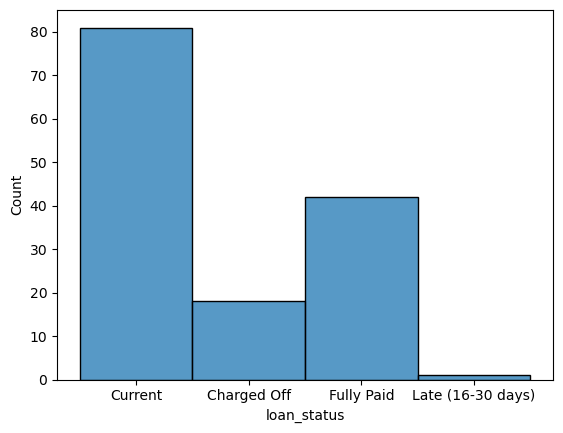

In [147]:
sns.histplot(temp_data.loc[temp_data['dti']==999,:]['loan_status'])

In [133]:
def null_dist(data : pd.DataFrame, label : str, null_feature : str)->None:
    null_idx=data[data[null_feature].isnull()].index
    num_null_data=data.loc[null_idx]
    med=data[null_feature].median()
    avg=int(data[null_feature].mean())
    min=data[null_feature].min()
    max=data[null_feature].max()
    list1=[0,med,avg,min,max]
    data[label] = data[label].astype(str)
    num_null_data[label] = num_null_data[label].astype(str)
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 30))
    subset = data[label]
    sns.histplot(subset, ax=axes[0, 0], bins=30, kde=False)
    axes[0, 0].set_title(f'{null_feature} Distribution')
    axes[0,0].tick_params( rotation=45, labelsize=6)
    subset = num_null_data[label]
    sns.histplot(subset, ax=axes[0,1], bins=30, kde=False)
    axes[0, 1].set_title('Null Data Distribution')
    axes[0, 1].tick_params( rotation=45, labelsize=6)
    j=0
    for i in list1:
        row = (j+2) // 3  # 행 위치 (3번째부터는 새로운 행)
        col = (j+2) % 3   # 열 위치
        subset = data[data[null_feature] == i]
        sns.histplot(subset[label], ax=axes[row, col], kde=False)
        axes[row, col].set_title(f'{label} Distribution for {i}')
        axes[row, col].set_xticks(axes[row, col].get_xticks())
        axes[row, col].tick_params( rotation=45, labelsize=6)
        # axes[row, col].set_xticks(common_xticks)
        j+=1

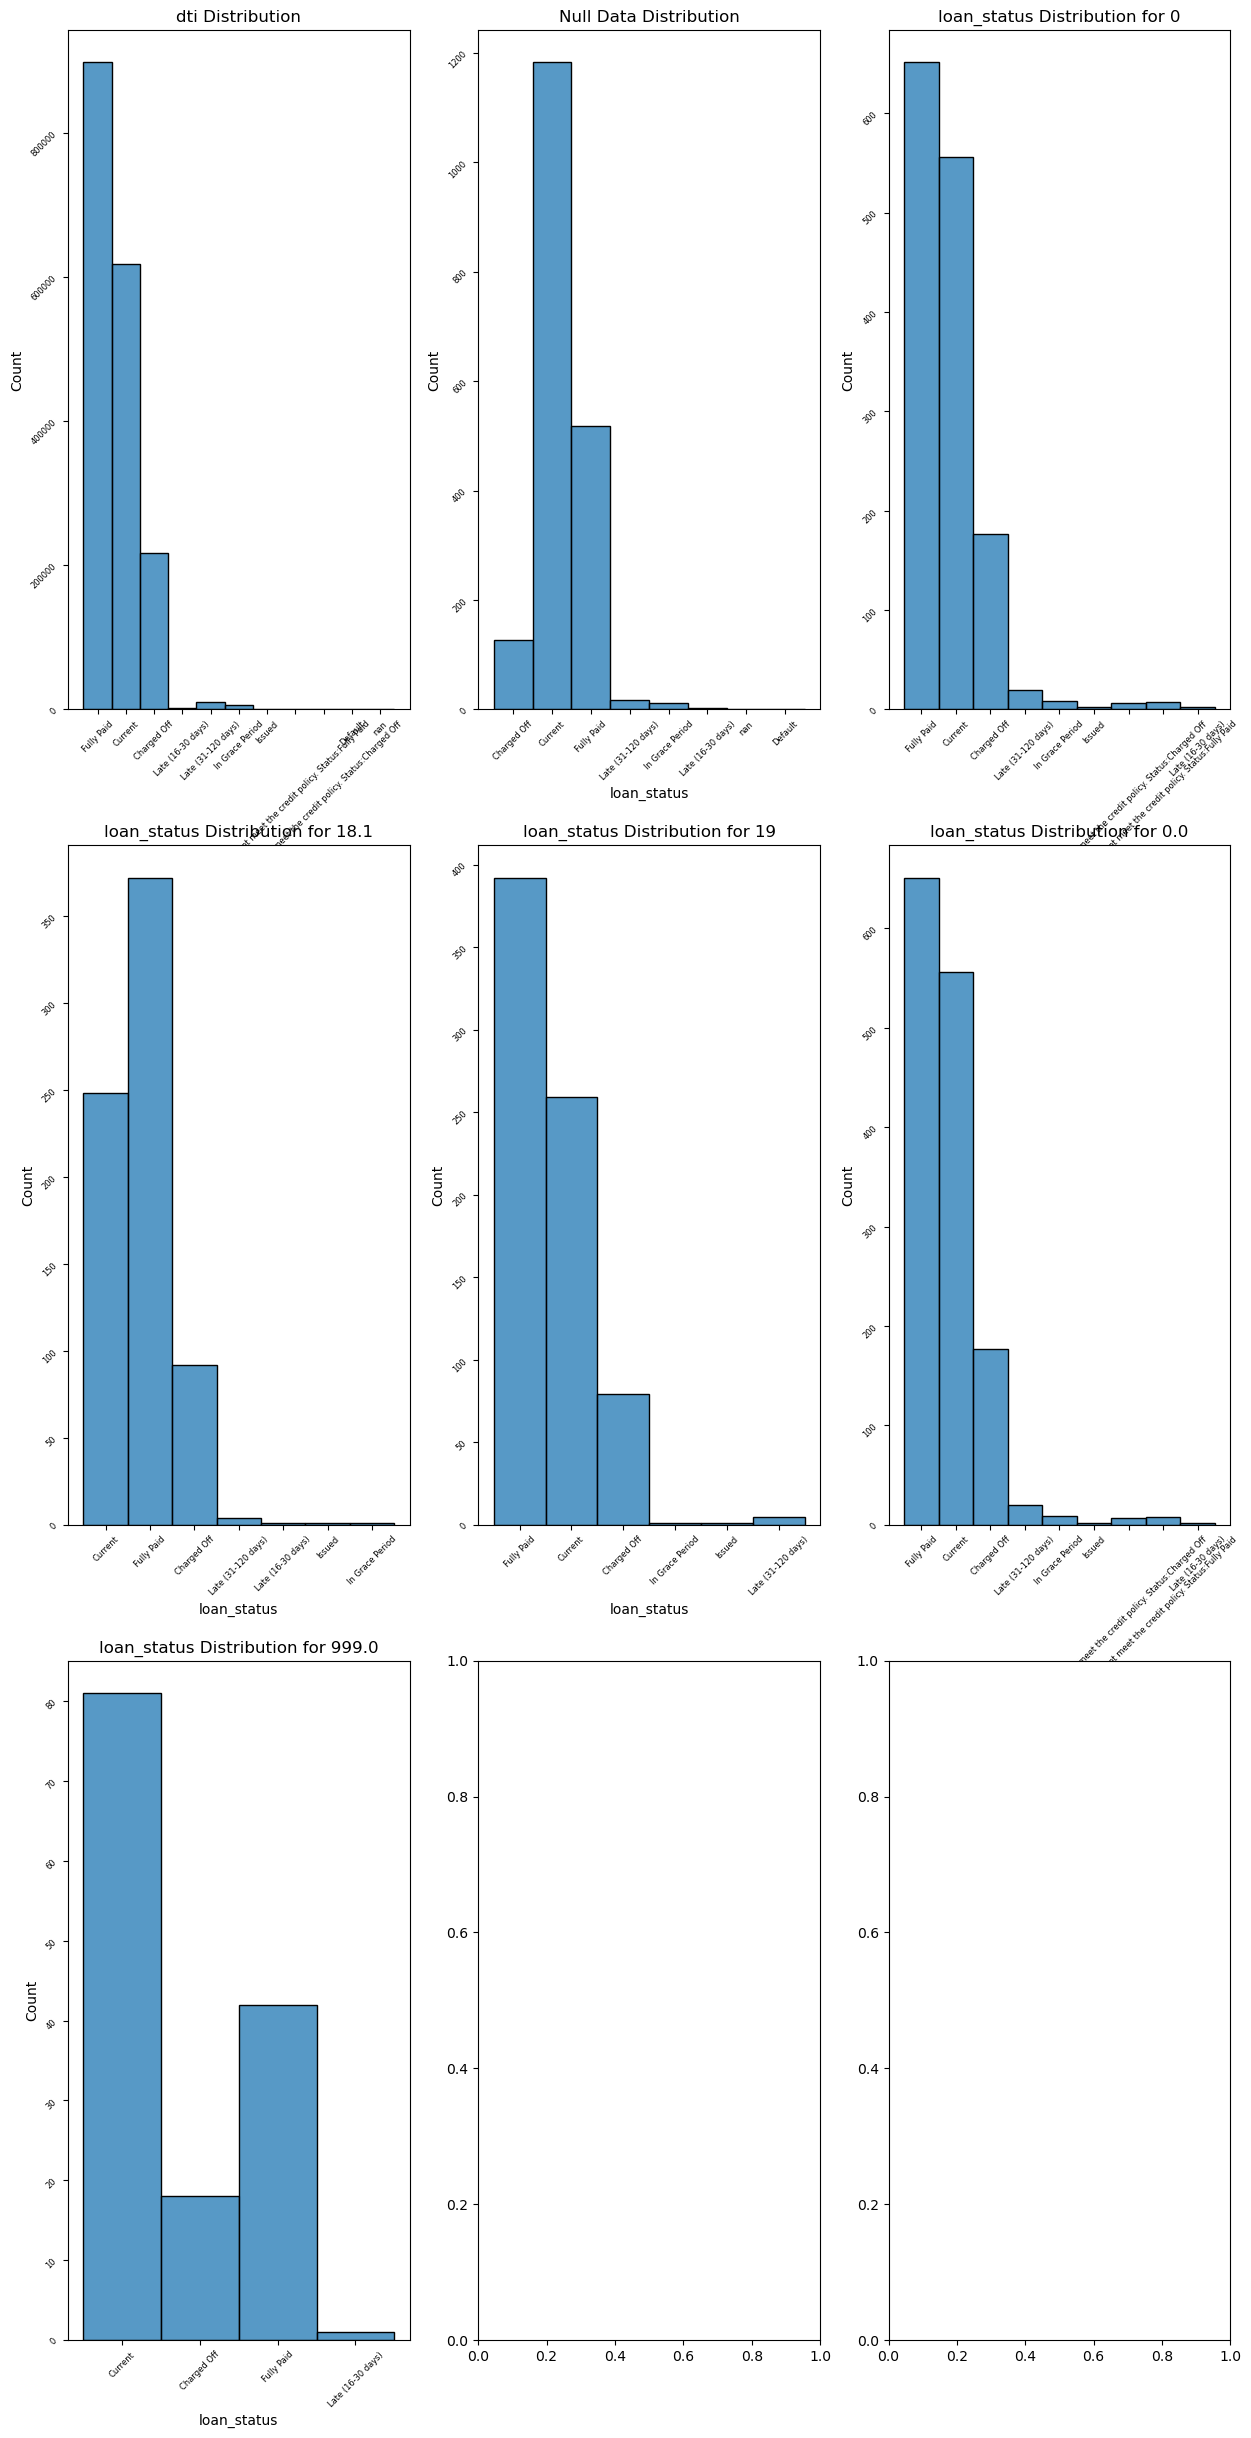

In [135]:
null_dist(temp_data,'loan_status','dti')